In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

import processing as proc
import metricas
import dataset

In [31]:
## Funcoes Aux

def draw_hist(x_axis, input):
    fig, ax = plt.subplots(figsize=(4,4))
    # por que não usar plt.hist? porque queremos traçar também algumas derivações desse histograma
    plt.bar(x_axis, input, width=input.shape[0] / (x_axis[-1] - x_axis[0] + 1))
    return fig, ax


(<PIL.Image.Image image mode=RGB size=64x64 at 0x7412203275C0>, array([3]))


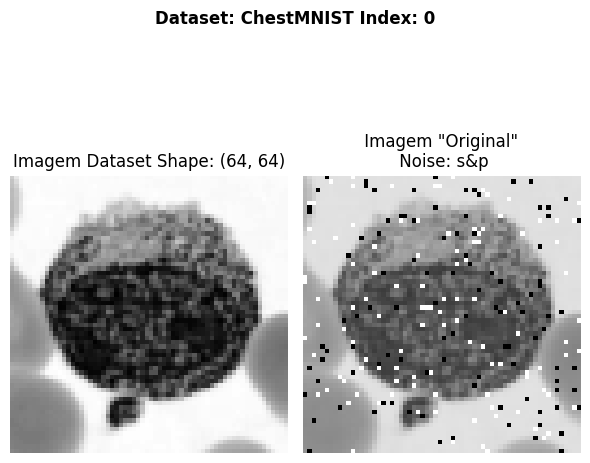

IndexError: arrays used as indices must be of integer (or boolean) type

In [70]:
##
raw_ds = dataset.create_dataset(1, False)
##
modes = ["gaussian","localvar", "poisson", "salt", "pepper", "s&p" ,  "speckle"]
noise_mode = modes[5]
n_ds = []
##


for i in range(len(raw_ds)):
    img = proc.prep_img(raw_ds[i])
    n_img = proc.add_noise(img, noise_mode)
    n_ds.append(n_img)

    #  Show DataSet
    fig, axes = plt.subplots(1, 2, figsize=(6, 6))
    fig.suptitle(f"Dataset: ChestMNIST Index: {i}" , fontsize=12, fontweight='bold')
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'Imagem Dataset Shape: {img.shape}')
    axes[0].axis('off')

    axes[1].imshow(n_img, cmap='gray')
    axes[1].set_title(f' Imagem "Original" \n Noise: {noise_mode}')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()


    ### Transformações
    img_eq = proc.hist_norm(n_img)


    img_gamma = proc.gamma_correction(img_eq, 0.7)

    

    conv_mediana = proc.convolution(img_gamma, "Mediana")
    conv_gauss = proc.convolution(img_gamma, "Gauss")  
    conv_media = proc.convolution(img_gamma, "Media")
    connv_sobel = proc.convolution(img_gamma, "Gauss")

    
    fig, axs = plt.subplots(3, 2, figsize=(6, 6))
    fig.suptitle(f"Convoluções Aplicadas: {i}" , fontsize=12, fontweight='bold')

    axs[0,0].imshow(img_eq, cmap='gray')
    axs[0,0].set_title(f'Historiograma Normalizada')
    axs[0,0].axis('off')
    
    axs[0,1].imshow(img_gamma, cmap='gray')
    axs[0,1].set_title(f'Gamma Corrigido')
    axs[0,1].axis('off')

    axs[1,0].imshow(conv_media, cmap='gray')
    axs[1,0].set_title(f' Media 3x3')
    axs[1,0].axis('off')

    axs[1,1].imshow(connv_sobel, cmap='gray')
    axs[1,1].set_title(f' Sobel 3x3')
    axs[1,1].axis('off')

    axs[2,0].imshow(conv_mediana, cmap='gray')
    axs[2,0].set_title(f' Mediana 3x3')
    axs[2,0].axis('off')
    
    axs[2,1].imshow(conv_gauss, cmap='gray')
    axs[2,1].set_title(f' Gauss 3x3')
    axs[2,1].axis('off')




    plt.show()




    ## Testes


    #3Show one img

    #plt.figure(figsize=(3, 3))
    #plt.imshow(img_eq, cmap="gray")
    #plt.title("Historiograma Normalizada")
    #plt.show()



    #point_start, point_count = metricas.hist(img)
    #draw_hist(point_start, point_count)
    #plt.title("Histograma Orginal")
    #plt.show()

    ### Normalizaco historigrama pelo cv2
    #img_eq_cv2 = cv2.equalizeHist(n_img)

    #plt.figure(figsize=(3, 3))
    #plt.imshow(img_eq_cv2, cmap="gray")
    #plt.title("Resultado cv2.equalizeHist()")
    #plt.show()
    #point_start, point_count = metricas.hist(img_eq_cv2)
    #draw_hist(point_start, point_count)
    #plt.title("Histograma  cv2.equalizeHist()")
    #plt.show()



    



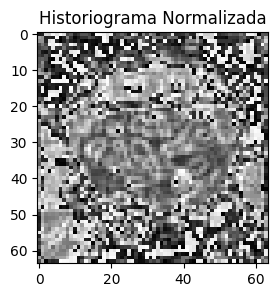

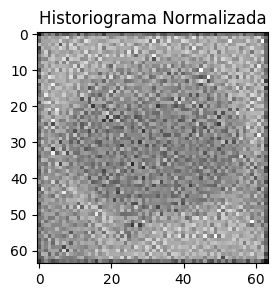

In [66]:

ss =    proc.conv2d_sharpening(conv_mediana, proc.get_kernel("sobel_1"))
sss =   proc.conv2d_sharpening(conv_mediana, proc.get_kernel("sobel_2"))
img_sobel = np.array(np.abs(ss)+np.abs(sss), dtype=np.uint8)

o_img =  conv_mediana + img_sobel


plt.figure(figsize=(3, 3))
plt.imshow(o_img, cmap="gray")
plt.title("Historiograma Normalizada")
plt.show()


l = proc.conv2d_sharpening(n_img, proc.get_kernel("laplac"))
plt.figure(figsize=(3, 3))
plt.imshow(l+conv_mediana, cmap="gray")
plt.title("Historiograma Normalizada")
plt.show()


### Historiograma